In [1]:
%gui asyncio
%autoawait asyncio

In [6]:
import ipywidgets as widgets
debug_view = widgets.Output(layout={'border': '1px solid black'})

In [7]:
import asyncio
def wait_for_change(widget, value):
    future = asyncio.Future()
    def getvalue(change):
        # make the new value available
        future.set_result(change.new)
        widget.unobserve(getvalue, value)
    widget.observe(getvalue, value)
    return future

In [10]:
from ipywidgets import IntSlider
slider = IntSlider()
@debug_view.capture(clear_output=True)
async def f():
    for i in range(10):
        print('did work %s'%i)
        x = await wait_for_change(slider, 'value')
        print('async function continued with value %s'%x)
asyncio.ensure_future(f())

slider

IntSlider(value=0)

did work 0


In [11]:
debug_view

Output(layout=Layout(border='1px solid black'))

In [90]:
import ipywidgets as widgets
out = widgets.Output(layout={'border': '1px solid black'})
out.append_display_data(HTML('Hello world!'))
out.append_display_data(HTML('Hello world!'))

HTML(value='Hello world!')

HTML(value='Hello world!')

In [34]:
import asyncio
from concurrent.futures import ThreadPoolExecutor

aio_pool = ThreadPoolExecutor(1)
aio_loop = asyncio.new_event_loop()
aio_pool.submit(asyncio.set_event_loop, aio_loop).result()

async def mycoro():
    await asyncio.sleep(1)
    return 5

result = aio_pool.submit(aio_loop.run_until_complete, mycoro()).result()
result

5

In [48]:
from functools import wraps
def yield_for_change(widget, attribute):
    """Pause a generator to wait for a widget change event.
    This is a decorator for a generator function which pauses the generator on yield
    until the given widget attribute changes. The new value of the attribute is
    sent to the generator and is the value of the yield.
    """
    def f(iterator):
        @wraps(iterator)
        def inner():
            i = iterator()
            def next_i(change):
                try:
                    i.send(change.new)
                except StopIteration as e:
                    widget.unobserve(next_i, attribute)
            widget.observe(next_i, attribute)
            # start the generator
            next(i)
        return inner
    return f

In [49]:
from ipywidgets import IntSlider, VBox, HTML
slider2=IntSlider()
@yield_for_change(slider2, 'value')
def f():
    for i in range(10):
        print('did work %s'%i)
        x = yield
        print('generator function continued with value %s'%x)
f()
slider2

did work 0


IntSlider(value=0)

In [9]:
import threading
from IPython.display import display
import ipywidgets as widgets
import time
progress = widgets.FloatProgress(value=0.0, min=0.0, max=1.0)
def work(progress):
    total = 100
    for i in range(total):
        time.sleep(0.2)
        progress.value = float(i+1)/total
thread = threading.Thread(target=work, args=(progress,))
display(progress)
thread.start()

FloatProgress(value=0.0, max=1.0)

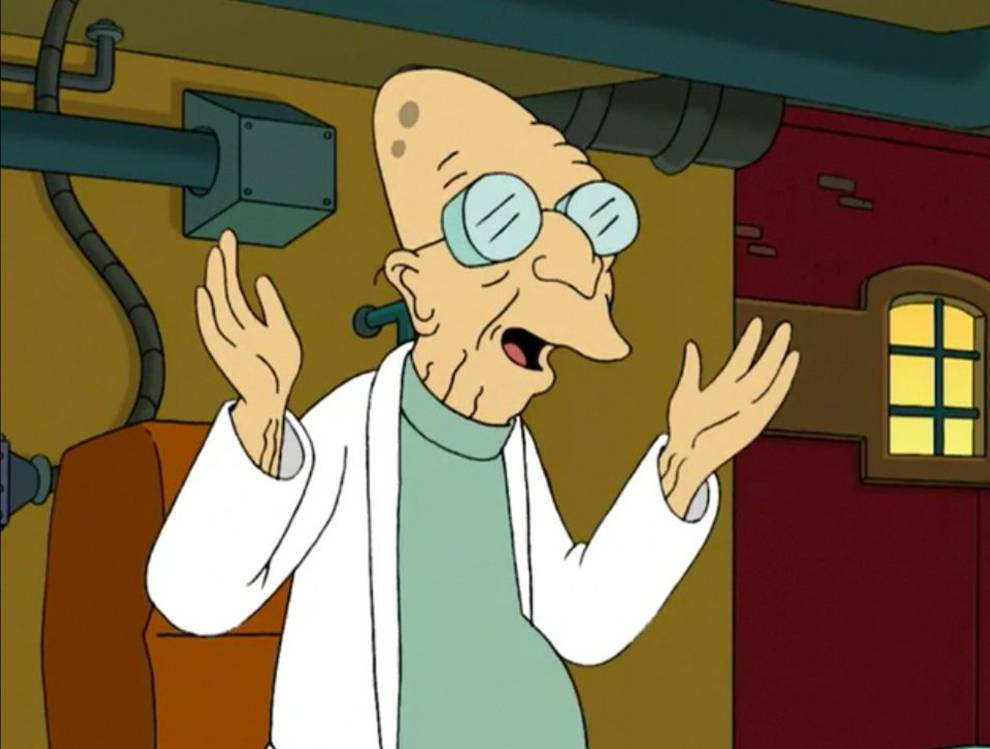

In [47]:
import aiohttp
from IPython.display import Image
# coro = aiohttp.get('https://vignette.wikia.nocookie.net/en.futurama/images/a/ad/GoodNewsEveryone.jpg')
# response = await coro

async def fetch(session, url):
    async with session.get(url) as response:
        return await response.read()

async with aiohttp.ClientSession() as session:
    img = await fetch(session, 'https://vignette.wikia.nocookie.net/en.futurama/images/a/ad/GoodNewsEveryone.jpg')
    display(Image(data=img))